# Analisis Univariado 


In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import skew, kurtosis

In [49]:
nombre = input("📝 Ingresa tu nombre completo: ")
correo = input("📧 Ingresa tu correo electrónico: ")
cedula = input("🔢 Ingresa los últimos 6 dígitos de tu cédula: ")

In [50]:
# generazion de datos aleatorios con semilla para reproducibilidad con desviazion estandar de 2 tamaño de muestra 100 y una media teorica de (base % 10) + 2

# Cedula = 443241
base = int(cedula)
np.random.seed(base)
media_teorica = (base % 10) + 2
datos = np.random.normal(loc=media_teorica, scale=2, size=100)
df = pd.DataFrame(datos, columns=['Valor'])
df.head()

ValueError: invalid literal for int() with base 10: ''

In [ ]:
# Eliminar valores negativos
df = df[df['Valor'] >= 0]

# Parte 1: Análisis Univariado

Ejercicio 1: Cálculo de medidas de tendencia central

Medidas de tendencia central:
Media:   3.02 ingresos
Mediana: 2.72 ingresos


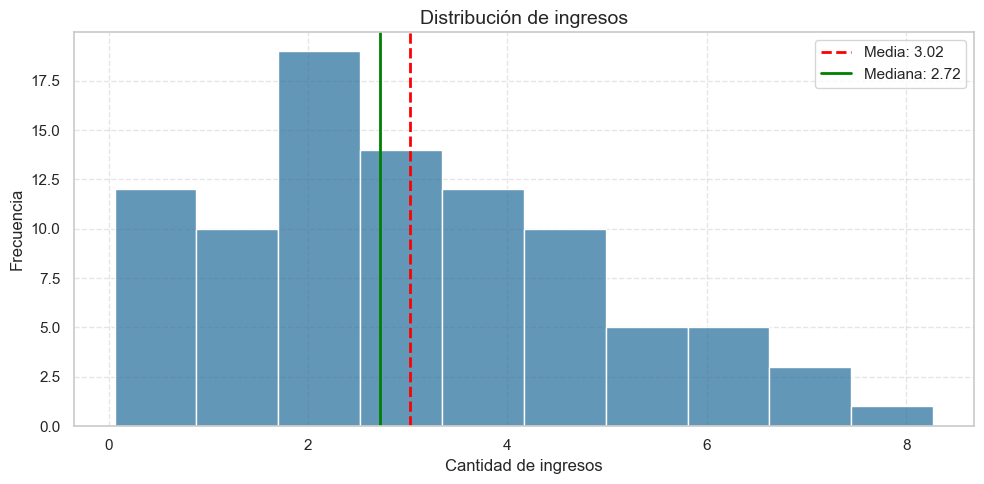

In [ ]:
media = np.mean(df['Valor'])
mediana = np.median(df['Valor'])
moda = stats.mode(df['Valor'], keepdims=True)[0][0]

# Resultados
print("Medidas de tendencia central:")
print(f"Media:   {media:.2f} ingresos")
print(f"Mediana: {mediana:.2f} ingresos")


plt.figure(figsize=(10, 5))
sns.histplot(df['Valor'], bins=10, kde=False, color="#2F749F")

# Líneas de tendencia central
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')

plt.title("Distribución de ingresos", fontsize=14)
plt.xlabel("Cantidad de ingresos", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Ejercicio 2: Cálculo de medidas de dispersión

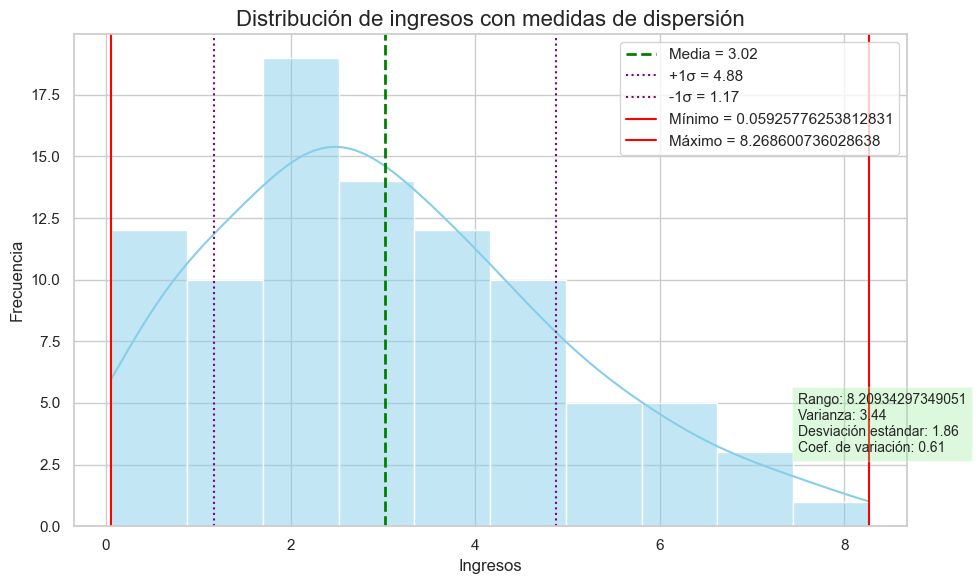

In [ ]:
# Datos simulados

# Cálculo de medidas de dispersión
media = np.mean(df['Valor'])
minimo = np.min(df['Valor'])
maximo = np.max(df['Valor'])
rango = maximo - minimo
varianza = np.var(df['Valor'], ddof=1)
desviacion = np.std(df['Valor'], ddof=1)
coef_var = desviacion / media

# Visualización
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df['Valor'], bins=10, kde=True, color='skyblue')

plt.axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
plt.axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'+1σ = {media + desviacion:.2f}')
plt.axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'-1σ = {media - desviacion:.2f}')
plt.axvline(minimo, color='red', linestyle='-', linewidth=1.5, label=f'Mínimo = {minimo}')
plt.axvline(maximo, color='red', linestyle='-', linewidth=1.5, label=f'Máximo = {maximo}')

plt.title("Distribución de ingresos con medidas de dispersión", fontsize=16)
plt.xlabel("Ingresos")
plt.ylabel("Frecuencia")
plt.legend()

# Recuadro con medidas
texto = (
    f"Rango: {rango}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}"
)
plt.text(7.5, 3, texto, bbox=dict(facecolor='lightgreen', alpha=0.3), fontsize=10)

plt.tight_layout()
plt.show()

Ejercicio 3: Cálculo de medidas de distribución

Asimetría: 0.6
Curtosis: -0.14


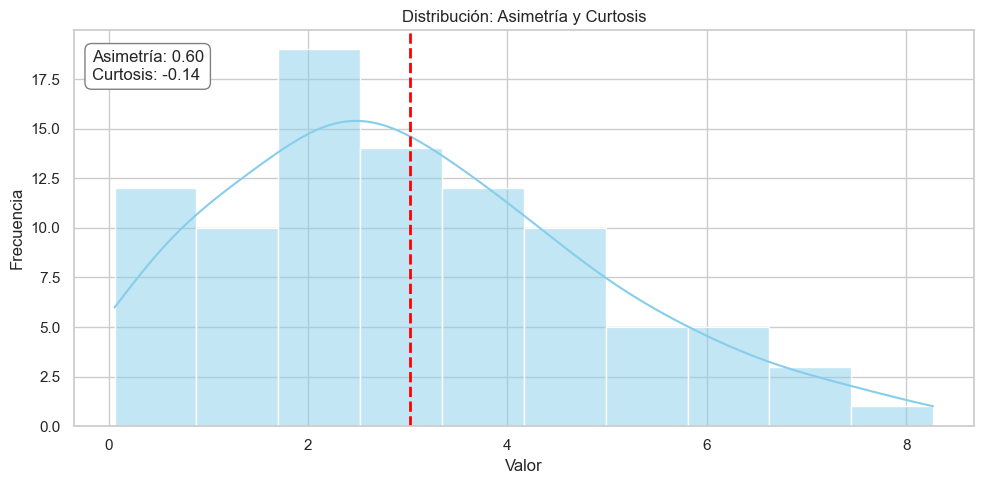

In [ ]:
asimetria = skew(df['Valor'])
curtosis_valor = kurtosis(df['Valor'], fisher=True)

print("Asimetría:", round(asimetria, 2))
print("Curtosis:", round(curtosis_valor, 2))

plt.figure(figsize=(10, 5))
sns.histplot(df['Valor'], bins=10, kde=True, color='skyblue')

plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
plt.title("Distribución: Asimetría y Curtosis")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")

plt.text(0.02, 0.95,
         f"Asimetría: {asimetria:.2f}\nCurtosis: {curtosis_valor:.2f}",
         transform=plt.gca().transAxes,
         verticalalignment="top",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray"))

plt.tight_layout()
plt.show()

Ejercicio 4: Cálculo de medidas de percentiles

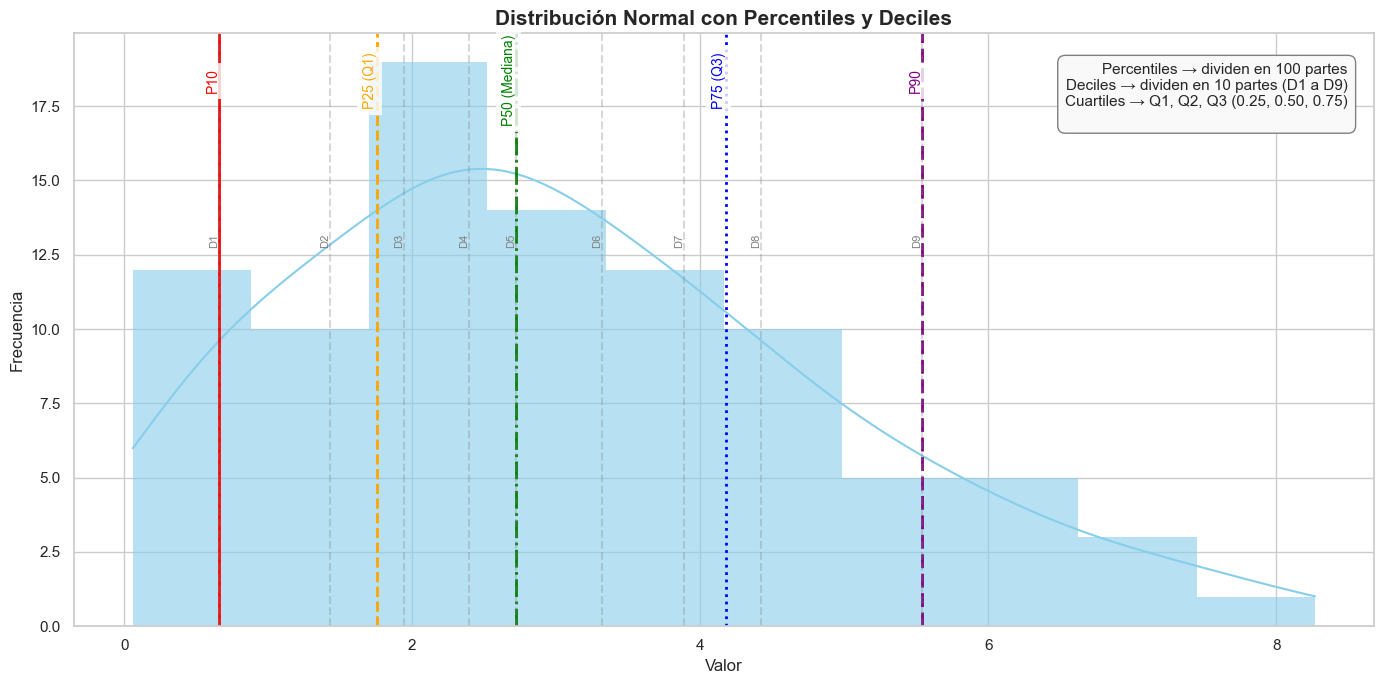

In [ ]:
datos = df['Valor']
percentiles = {
    'P10': {'valor': np.percentile(datos, 10), 'color': 'red', 'linestyle': '-'},
    'P25 (Q1)': {'valor': np.percentile(datos, 25), 'color': 'orange', 'linestyle': '--'},
    'P50 (Mediana)': {'valor': np.percentile(datos, 50), 'color': 'green', 'linestyle': '-.'},
    'P75 (Q3)': {'valor': np.percentile(datos, 75), 'color': 'blue', 'linestyle': ':'},
    'P90': {'valor': np.percentile(datos, 90), 'color': 'purple', 'linestyle': (0, (5, 2))}
}

# Cálculo de deciles (D1 a D9)
deciles = {f'D{i}': np.percentile(datos, i * 10) for i in range(1, 10)}

# Visualización
plt.figure(figsize=(14, 7))
sns.histplot(datos, kde=True, color='skyblue', bins=10, edgecolor="None", alpha=0.6)

# Líneas verticales de percentiles
for etiqueta, props in percentiles.items():
    plt.axvline(props['valor'], color=props['color'], linestyle=props['linestyle'], linewidth=2)
    plt.text(props['valor'], plt.ylim()[1]*0.92, etiqueta,
             rotation=90, color=props['color'], fontsize=10,
             verticalalignment='center', horizontalalignment='right',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Líneas verticales de deciles
for etiqueta, valor in deciles.items():
    plt.axvline(valor, color='gray', linestyle='--', alpha=0.3)
    plt.text(valor, plt.ylim()[1]*0.65, etiqueta,
             rotation=90, color='gray', fontsize=8,
             verticalalignment='center', horizontalalignment='right')

texto = (
    "Percentiles → dividen en 100 partes\n"
    "Deciles → dividen en 10 partes (D1 a D9)\n"
    "Cuartiles → Q1, Q2, Q3 (0.25, 0.50, 0.75)\n")
plt.text(0.98, 0.95, texto, transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#f9f9f9", edgecolor="gray"))

plt.title("Distribución Normal con Percentiles y Deciles", fontsize=15, fontweight='bold')
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Parte 2: Análisis Bivariado

generamos un dataset de ejemplo


In [ ]:
# Cedula = 752246
np.random.seed(base)
media_teorica = (base % 10) + 2
Ingresos = np.random.normal(loc=media_teorica, scale=2, size=100)
gastos = np.random.normal(loc=media_teorica, scale=2, size=100)
df_2 = pd.DataFrame(Ingresos, columns=['Ingresos'])
df_2['Gastos'] = gastos
df_2.head()

,Ingresos,Gastos
0,5.276132,0.366908
1,1.503996,2.993012
2,1.822913,2.788456
3,3.370511,0.346600
4,8.268601,4.586835


In [ ]:
df_2 = df_2[df_2['Ingresos'] >= 0]
df_2 = df_2[df_2['Gastos'] >= 0]

In [ ]:
def plot_corr(ax, x, y, r, title, color):
    ax.scatter(x, y, alpha=0.6, color=color, label=f"r = {r:.2f}")

    # Línea de tendencia
    m, b = np.polyfit(x, y, 1)  # ajuste lineal (pendiente y corte)
    ax.plot(x, m*x + b, color="black", linewidth=2, linestyle="--", label="Tendencia")

    ax.set_title(title)
    ax.set_xlabel("Variable X")
    ax.set_ylabel("Variable Y")
    ax.legend()

Ejercicio 5: Análisis de correlación

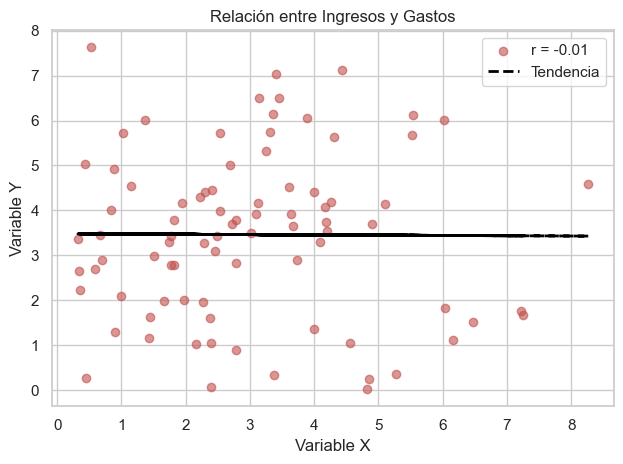

In [ ]:
from scipy.stats import pearsonr
r, _ = pearsonr(df_2['Ingresos'], df_2['Gastos'])

plot_corr(plt.gca(), df_2['Ingresos'], df_2['Gastos'], r, "Relación entre Ingresos y Gastos", "#C0504D")
plt.tight_layout()

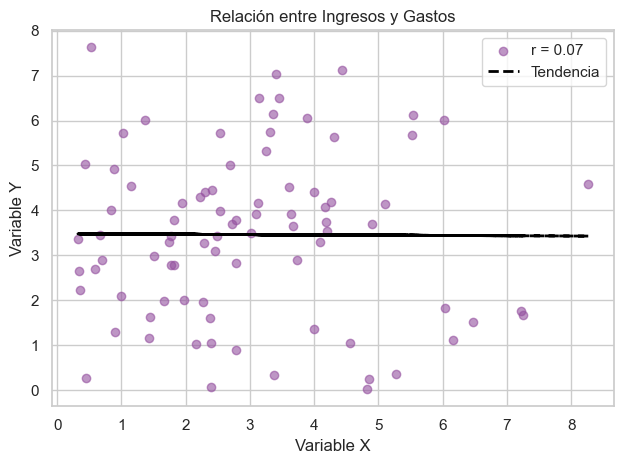

In [ ]:
from scipy.stats import spearmanr
rho, _ = spearmanr(df_2['Ingresos'], df_2['Gastos'])
plot_corr(plt.gca(), df_2['Ingresos'], df_2['Gastos'], rho, "Relación entre Ingresos y Gastos", "#94509F")
plt.tight_layout()

Segun los resultados de la correlacion tanto para Spearman como para Pearson, se observa un r que esta muy cercano a 0, lo que indica que no hay una relación lineal fuerte entre las variables "Ingresos" y "Gastos". Esto sugiere que los ingresos no son un buen predictor de los gastos en este conjunto de datos. lo que indica que no se puede concluir que a medida que aumentan los ingresos, los gastos también aumentan o disminuyen de manera consistente.


Ejercicio 6: Chi-Cuadrado

In [ ]:
from scipy.stats import chi2_contingency


np.random.seed(base)
nivel_educativo = np.random.choice(["Básico", "Medio", "Superior"], size=60)
acceso_internet = np.random.choice(["Sí", "No"], size=60)

df = pd.DataFrame({
    "Nivel educativo": nivel_educativo,
    "Acceso a internet": acceso_internet
})

tabla = pd.crosstab(df["Nivel educativo"], df["Acceso a internet"])

In [ ]:
tabla

Acceso a internet,No,Sí
Nivel educativo,,
Básico,7,16
Medio,11,12
Superior,5,9


Tabla de contingencia (Nivel educativo vs Acceso a internet):
Acceso a internet  No  Sí
Nivel educativo          
Básico              7  16
Medio              11  12
Superior            5   9 

Chi2 = 1.524, p-valor = 0.467, grados de libertad = 2



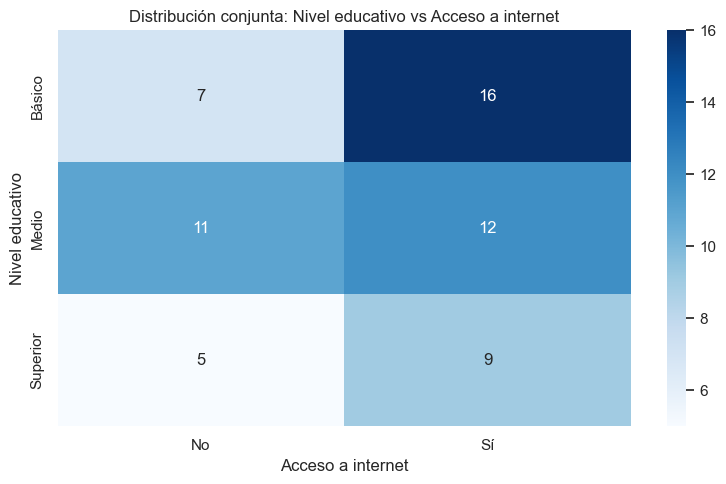

Interpretación:
- p ≥ 0.05 → No hay evidencia suficiente de asociación; parecen independientes.


In [ ]:
chi2, p, dof, expected = chi2_contingency(tabla)

print("Tabla de contingencia (Nivel educativo vs Acceso a internet):")
print(tabla, "\n")
print(f"Chi2 = {chi2:.3f}, p-valor = {p:.3f}, grados de libertad = {dof}\n")
plt.figure(figsize=(8, 5))
sns.heatmap(tabla, annot=True, fmt="d", cmap="Blues", cbar=True)

plt.title("Distribución conjunta: Nivel educativo vs Acceso a internet")
plt.xlabel("Acceso a internet")
plt.ylabel("Nivel educativo")
plt.tight_layout()
plt.show()
print("Interpretación:")
if p < 0.05:
    print("- p < 0.05 → Hay evidencia de asociación entre nivel educativo y acceso a internet.")
else:
    print("- p ≥ 0.05 → No hay evidencia suficiente de asociación; parecen independientes.")

# Analisis Multivariado

In [63]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

In [64]:
df = pd.read_csv(r"C:\Users\eduar\Documents\Maestria\2do Semestre\Analisis de Datos\Proyecto-Ciencia-de-Datos-kathe-y-Edu-\datos\breast_cancer_wisconsin_diagnostic_original.csv",
                    index_col=0, sep=";")
df

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
ID,,,,,,,,,,,,,,,,,,,,,
842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,M
842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,M
84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,M
84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,M
84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926424,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,M
926682,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,M
926954,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,M


In [65]:
# Columna objetivo (clase)
df["Diagnosis"] = df["Diagnosis"].astype(str).str.upper()   # B / M

# Variables numéricas (features): todo menos ID y Diagnosis
feature_names = [c for c in df.columns if c not in ["ID", "Diagnosis"]]

# Convertir a numérico por seguridad
for c in feature_names:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Estandarizar variables numéricas
scaler = StandardScaler()
X_std = scaler.fit_transform(df[feature_names])

In [75]:
# PCA para las 30 variables numéricas
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_std)


# # IMPORTANTE: con 30 variables el pairplot queda gigante.
# # Para mantener el mismo estilo sin que explote el notebook, usamos un subset representativo.
# pair_vars = ["radius1", "texture1", "perimeter1", "area1", "concavity1", "concave_points1"]
# pair_vars = [v for v in pair_vars if v in df.columns]

# sns.pairplot(df[pair_vars + ["Diagnosis"]], hue="Diagnosis", diag_kind="hist", corner=False)
# plt.suptitle("Matriz de dispersión: relaciones entre variables (subset)", fontsize=16, y=1.02)
# plt.show()

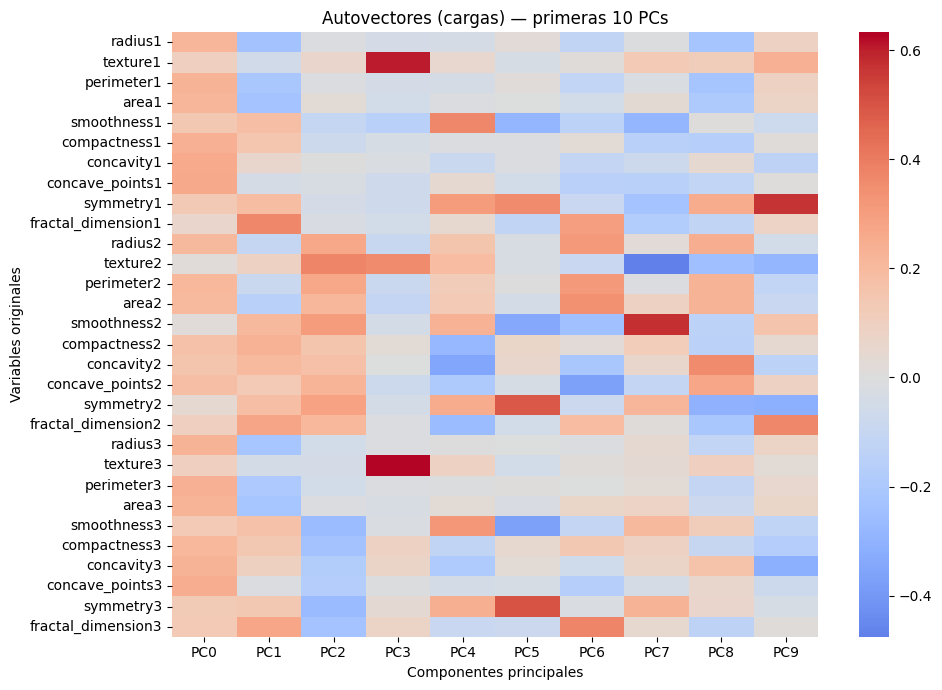

In [76]:

# Matriz de componentes (autovectores)
componentes = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i}" for i in range(10)],
    index=feature_names
)

# Visualización de autovectores
plt.figure(figsize=(10, 7))
sns.heatmap(componentes.iloc[:,:10], annot=False, cmap="coolwarm", center=0)  # muestro solo PC1–PC10 para legibilidad
plt.title("Autovectores (cargas) — primeras 10 PCs")
plt.ylabel("Variables originales")
plt.xlabel("Componentes principales")
plt.tight_layout()
plt.show()

In [77]:
# Ecuaciones de los componentes principales con nombres reales (primeras 3 PCs para que no sea infinito)
print("Ecuaciones de los componentes principales (primeras 3 PCs):\n")
for i, comp in enumerate(componentes.columns[:3]):
    pesos = pca.components_[i]
    ecuacion = " + ".join([f"{round(pesos[j], 3)}·'{feature_names[j]}'" for j in range(len(pesos))])
    print(f"{comp} = {ecuacion}\n")

varianza = pca.explained_variance_
PVE = pca.explained_variance_ratio_
PVE_acum = np.cumsum(PVE)
componentes_labels = [f"PC{i+1}" for i in range(len(PVE))]

df_varianza = pd.DataFrame({
    "Componente": componentes_labels,
    "Autovalor": varianza,
    "PVE": PVE,
    "PVE acumulada": PVE_acum
})

print("Matriz resumen de varianza explicada:\n")
print(df_varianza.round(3))

Ecuaciones de los componentes principales (primeras 3 PCs):

PC0 = 0.219·'radius1' + 0.104·'texture1' + 0.228·'perimeter1' + 0.221·'area1' + 0.143·'smoothness1' + 0.239·'compactness1' + 0.258·'concavity1' + 0.261·'concave_points1' + 0.138·'symmetry1' + 0.064·'fractal_dimension1' + 0.206·'radius2' + 0.017·'texture2' + 0.211·'perimeter2' + 0.203·'area2' + 0.015·'smoothness2' + 0.17·'compactness2' + 0.154·'concavity2' + 0.183·'concave_points2' + 0.042·'symmetry2' + 0.103·'fractal_dimension2' + 0.228·'radius3' + 0.104·'texture3' + 0.237·'perimeter3' + 0.225·'area3' + 0.128·'smoothness3' + 0.21·'compactness3' + 0.229·'concavity3' + 0.251·'concave_points3' + 0.123·'symmetry3' + 0.132·'fractal_dimension3'

PC1 = -0.234·'radius1' + -0.06·'texture1' + -0.215·'perimeter1' + -0.231·'area1' + 0.186·'smoothness1' + 0.152·'compactness1' + 0.06·'concavity1' + -0.035·'concave_points1' + 0.19·'symmetry1' + 0.367·'fractal_dimension1' + -0.106·'radius2' + 0.09·'texture2' + -0.089·'perimeter2' + -0.152·'a

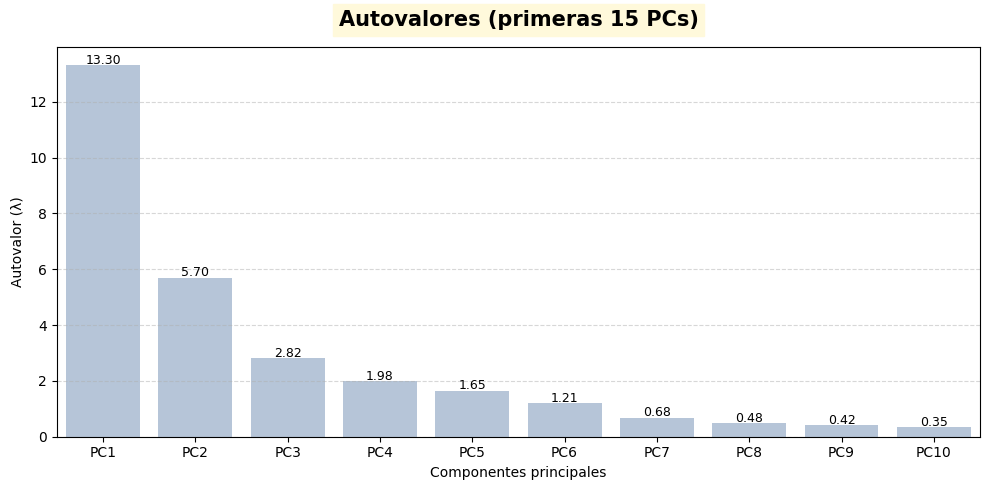

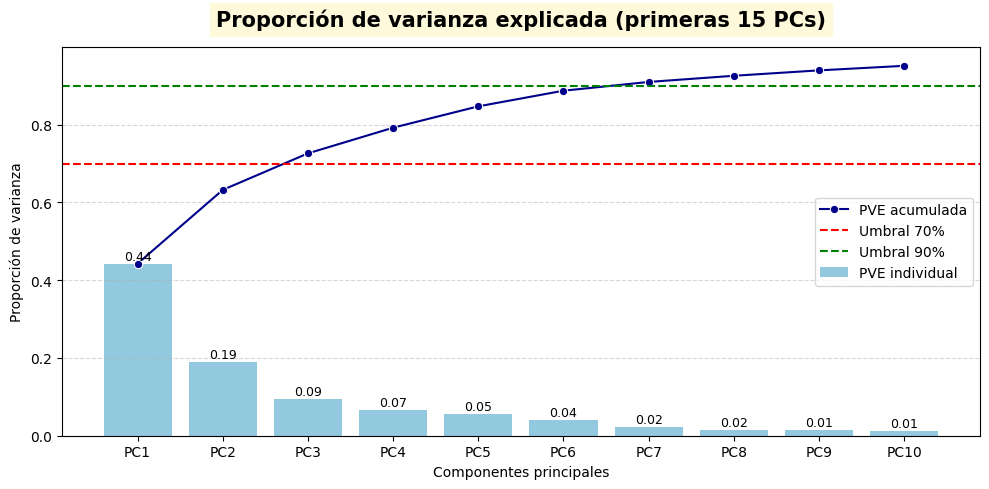

In [78]:

# Gráfico 1: Autovalores

plt.figure(figsize=(10, 5))
ax = sns.barplot(x="Componente", y="Autovalor", data=df_varianza.head(15), color="lightsteelblue")
for i, v in enumerate(df_varianza["Autovalor"].head(15)):
    ax.text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=9)
plt.title("Autovalores (primeras 15 PCs)", fontsize=15, fontweight="bold", backgroundcolor="#fff9db", pad=15)
plt.ylabel("Autovalor (λ)")
plt.xlabel("Componentes principales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Gráfico 2: Proporción de varianza explicada

plt.figure(figsize=(10, 5))
sns.barplot(x="Componente", y="PVE", data=df_varianza.head(15), color="skyblue", label="PVE individual")
sns.lineplot(x="Componente", y="PVE acumulada", data=df_varianza.head(15), marker="o", color="darkblue", label="PVE acumulada")

plt.axhline(0.7, color="red", linestyle="--", label="Umbral 70%")
plt.axhline(0.9, color="green", linestyle="--", label="Umbral 90%")

for i, v in enumerate(df_varianza["PVE"].head(15)):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=9, color="black")

plt.title("Proporción de varianza explicada (primeras 15 PCs)", fontsize=15, fontweight="bold", backgroundcolor="#fff9db", pad=15)
plt.ylabel("Proporción de varianza")
plt.xlabel("Componentes principales")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

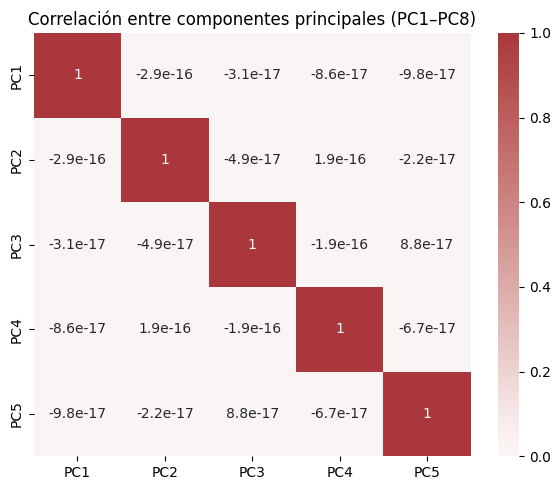

In [ ]:

# Paso 3: correlación entre PCs + proyección PC1 vs PC2

df_pca = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(len(PVE))])
correlaciones = df_pca.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(correlaciones.iloc[:5, :5], annot=True, cmap="vlag", center=0)  # muestro PC1–PC8 para legibilidad
plt.title("Correlación entre componentes principales (PC1–PC8)")
plt.tight_layout()
plt.show()



PCA por grupo (…1, …2, …3)

In [ ]:

# Definir 3 grupos (…1, …2, …3)
features_1 = [c for c in df.columns if c not in ["ID","Diagnosis"] and c.endswith("1")]
features_2 = [c for c in df.columns if c not in ["ID","Diagnosis"] and c.endswith("2")]
features_3 = [c for c in df.columns if c not in ["ID","Diagnosis"] and c.endswith("3")]

grupos = {
    "Grupo 1 (1 = promedio)": features_1,
    "Grupo 2 (2 = SE/variabilidad)": features_2,
    "Grupo 3 (3 = worst/extremos)": features_3
}

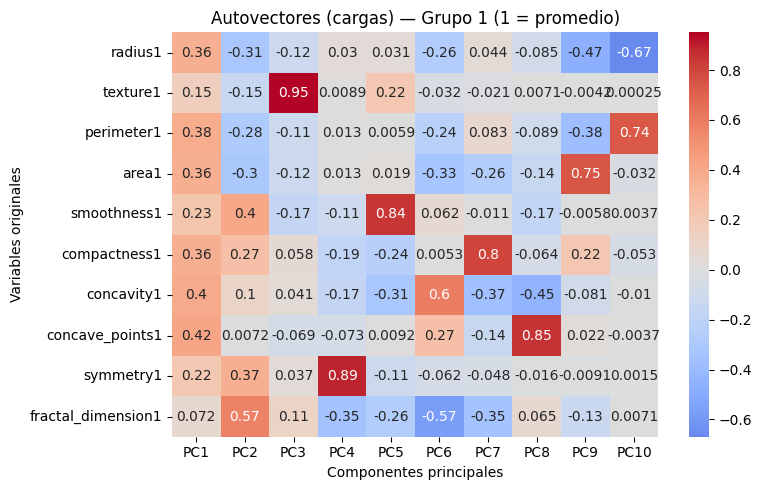


Ecuaciones de componentes principales — Grupo 1 (1 = promedio)

PC1 = 0.364·'radius1' + 0.154·'texture1' + 0.376·'perimeter1' + 0.364·'area1' + 0.232·'smoothness1' + 0.364·'compactness1' + 0.396·'concavity1' + 0.418·'concave_points1' + 0.215·'symmetry1' + 0.072·'fractal_dimension1'

PC2 = -0.314·'radius1' + -0.147·'texture1' + -0.285·'perimeter1' + -0.305·'area1' + 0.402·'smoothness1' + 0.266·'compactness1' + 0.104·'concavity1' + 0.007·'concave_points1' + 0.368·'symmetry1' + 0.572·'fractal_dimension1'

Matriz resumen de varianza explicada:

  Componente  Autovalor    PVE  PVE acumulada
0        PC1      5.488  0.548          0.548
1        PC2      2.523  0.252          0.800
2        PC3      0.882  0.088          0.888
3        PC4      0.500  0.050          0.938
4        PC5      0.373  0.037          0.975
5        PC6      0.124  0.012          0.987
6        PC7      0.080  0.008          0.995
7        PC8      0.035  0.003          0.999
8        PC9      0.011  0.001        

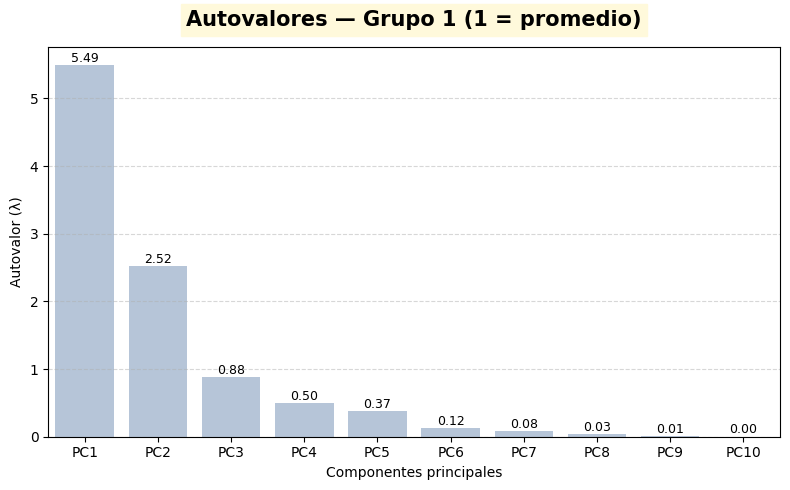

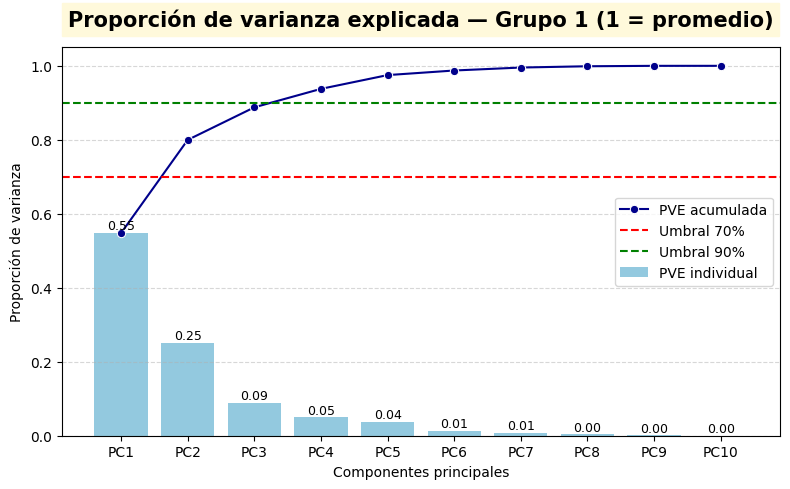

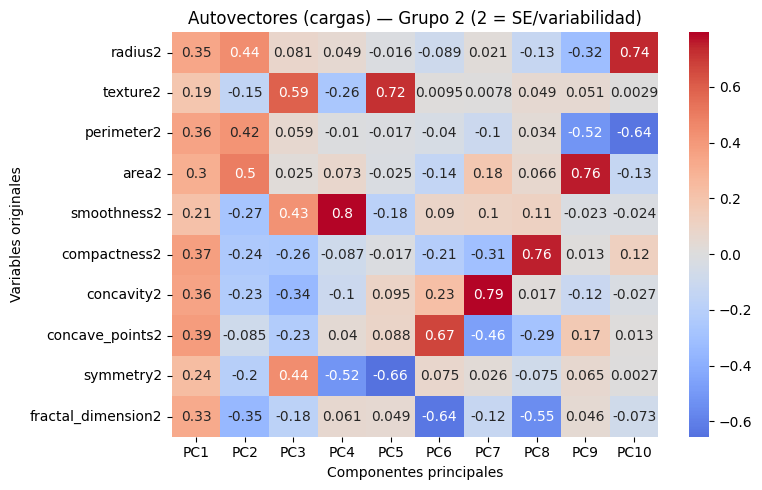


Ecuaciones de componentes principales — Grupo 2 (2 = SE/variabilidad)

PC1 = 0.346·'radius2' + 0.189·'texture2' + 0.357·'perimeter2' + 0.304·'area2' + 0.212·'smoothness2' + 0.375·'compactness2' + 0.356·'concavity2' + 0.386·'concave_points2' + 0.236·'symmetry2' + 0.329·'fractal_dimension2'

PC2 = 0.44·'radius2' + -0.153·'texture2' + 0.42·'perimeter2' + 0.5·'area2' + -0.271·'smoothness2' + -0.243·'compactness2' + -0.229·'concavity2' + -0.085·'concave_points2' + -0.199·'symmetry2' + -0.353·'fractal_dimension2'

Matriz resumen de varianza explicada:

  Componente  Autovalor    PVE  PVE acumulada
0        PC1      4.752  0.474          0.474
1        PC2      2.079  0.208          0.682
2        PC3      1.267  0.126          0.808
3        PC4      0.595  0.059          0.868
4        PC5      0.578  0.058          0.925
5        PC6      0.336  0.034          0.959
6        PC7      0.190  0.019          0.978
7        PC8      0.157  0.016          0.994
8        PC9      0.042  0.004  

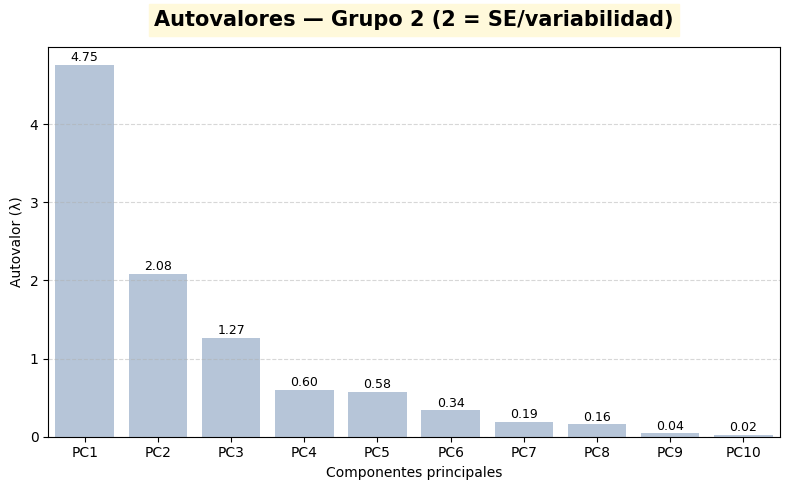

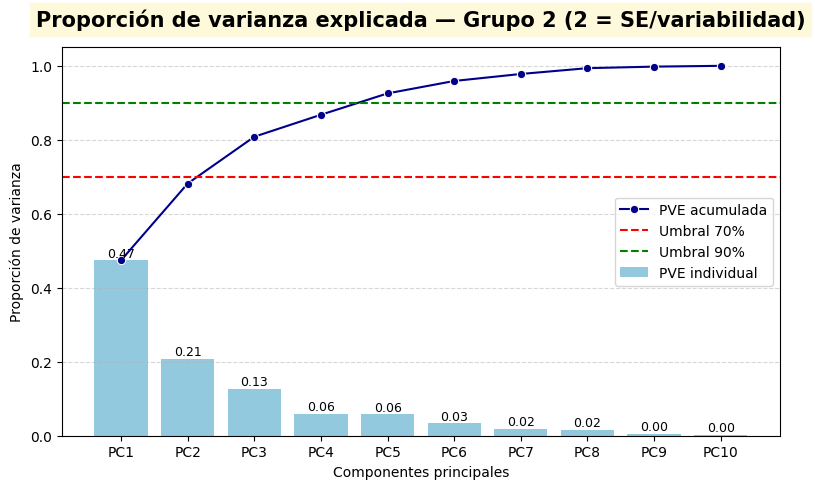

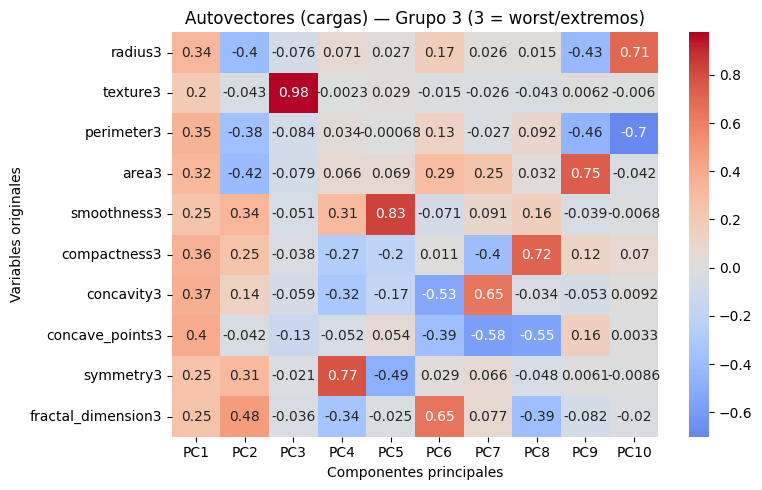


Ecuaciones de componentes principales — Grupo 3 (3 = worst/extremos)

PC1 = 0.336·'radius3' + 0.201·'texture3' + 0.348·'perimeter3' + 0.325·'area3' + 0.249·'smoothness3' + 0.365·'compactness3' + 0.375·'concavity3' + 0.398·'concave_points3' + 0.25·'symmetry3' + 0.254·'fractal_dimension3'

PC2 = -0.403·'radius3' + -0.043·'texture3' + -0.376·'perimeter3' + -0.415·'area3' + 0.338·'smoothness3' + 0.251·'compactness3' + 0.139·'concavity3' + -0.042·'concave_points3' + 0.309·'symmetry3' + 0.478·'fractal_dimension3'

Matriz resumen de varianza explicada:

  Componente  Autovalor    PVE  PVE acumulada
0        PC1      5.707  0.570          0.570
1        PC2      2.090  0.209          0.778
2        PC3      0.804  0.080          0.859
3        PC4      0.542  0.054          0.913
4        PC5      0.516  0.051          0.964
5        PC6      0.184  0.018          0.983
6        PC7      0.084  0.008          0.991
7        PC8      0.072  0.007          0.998
8        PC9      0.015  0.002  

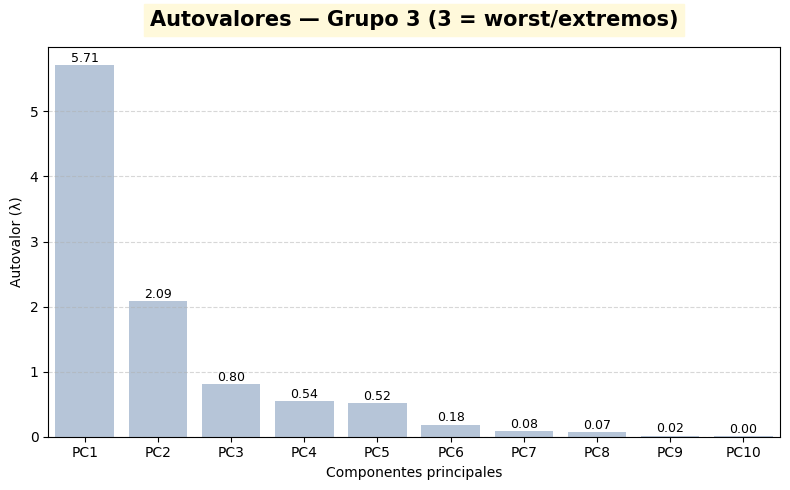

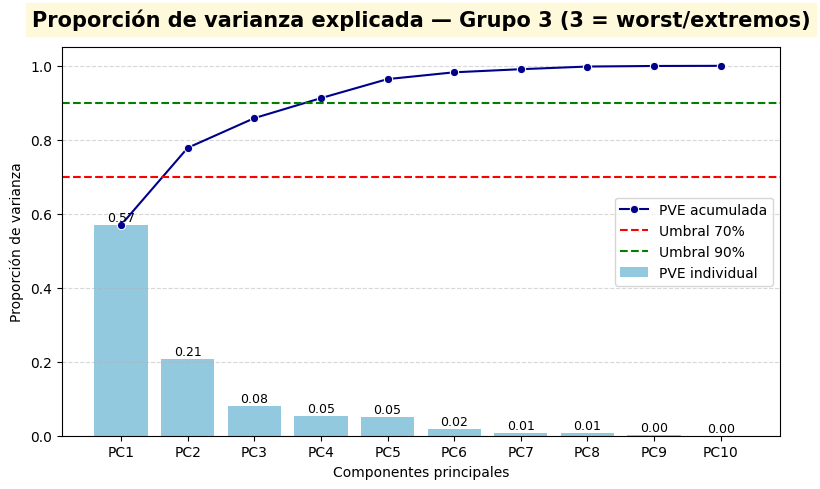

In [ ]:
for nombre_grupo, feature_names in grupos.items():

    # Estandarizar
    scaler = StandardScaler()
    X_std = scaler.fit_transform(df[feature_names])

    # PCA
    pca = PCA()
    X_pca = pca.fit_transform(X_std)


    # Matriz de componentes (autovectores)
    componentes = pd.DataFrame(
        pca.components_.T,
        columns=[f"PC{i+1}" for i in range(len(feature_names))],
        index=feature_names
    )

    plt.figure(figsize=(8, 5))
    sns.heatmap(componentes, annot=True, cmap="coolwarm", center=0)
    plt.title(f"Autovectores (cargas) — {nombre_grupo}")
    plt.ylabel("Variables originales")
    plt.xlabel("Componentes principales")
    plt.tight_layout()
    plt.show()

    # Ecuaciones (primeras 2 PCs para que no sea eterno)
    print("\n" + "="*80)
    print(f"Ecuaciones de componentes principales — {nombre_grupo}\n")
    for i, comp in enumerate(componentes.columns[:2]):
        pesos = pca.components_[i]
        ecuacion = " + ".join([f"{round(pesos[j], 3)}·'{feature_names[j]}'" for j in range(len(pesos))])
        print(f"{comp} = {ecuacion}\n")


    # Varianza explicada

    varianza = pca.explained_variance_
    PVE = pca.explained_variance_ratio_
    PVE_acum = np.cumsum(PVE)
    componentes_labels = [f"PC{i+1}" for i in range(len(PVE))]

    df_varianza = pd.DataFrame({
        "Componente": componentes_labels,
        "Autovalor": varianza,
        "PVE": PVE,
        "PVE acumulada": PVE_acum
    })

    print("Matriz resumen de varianza explicada:\n")
    print(df_varianza.round(3))


    # Gráfico 1: Autovalores
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(x="Componente", y="Autovalor", data=df_varianza, color="lightsteelblue")
    for i, v in enumerate(df_varianza["Autovalor"]):
        ax.text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=9)
    plt.title(f"Autovalores — {nombre_grupo}", fontsize=15, fontweight="bold", backgroundcolor="#fff9db", pad=15)
    plt.ylabel("Autovalor (λ)")
    plt.xlabel("Componentes principales")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Gráfico 2: Proporción de varianza explicada
    plt.figure(figsize=(8, 5))
    sns.barplot(x="Componente", y="PVE", data=df_varianza, color="skyblue", label="PVE individual")
    sns.lineplot(x="Componente", y="PVE acumulada", data=df_varianza, marker="o", color="darkblue", label="PVE acumulada")

    plt.axhline(0.7, color="red", linestyle="--", label="Umbral 70%")
    plt.axhline(0.9, color="green", linestyle="--", label="Umbral 90%")

    for i, v in enumerate(df_varianza["PVE"]):
        plt.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=9, color="black")

    plt.title(f"Proporción de varianza explicada — {nombre_grupo}", fontsize=15, fontweight="bold",
              backgroundcolor="#fff9db", pad=15)
    plt.ylabel("Proporción de varianza")
    plt.xlabel("Componentes principales")
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

